In [23]:
# Cell 1: Setup and Imports

# Basic libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Audio processing libraries
import librosa
import librosa.display

# For handling warnings
import warnings
warnings.filterwarnings("ignore")

# Make plots look better
plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


In [24]:
# === SETUP ===
current_dir = os.getcwd()  # Folder where this notebook runs (EDA/)
project_root = os.path.abspath(os.path.join(current_dir, ".."))  # Go one level up to project root

# Paths relative to project root
audio_root = os.path.join(project_root, "training_data", "training")  # training audio folder
plots_dir = os.path.join(current_dir, "Plots")  # Save plots locally inside EDA/Plots

# Make Plots folder if it does not exist
os.makedirs(plots_dir, exist_ok=True)

print("Setup complete!")
print("Current directory:", current_dir)
print("Project root:", project_root)
print("Audio root:", audio_root)
print("Plots folder:", plots_dir)


# =========================================================
# 2. LOAD DATA
# =========================================================
train_excel = os.path.join(project_root, "training_data", "sand_task_1.xlsx")
test_excel = os.path.join(project_root, "testing_data", "sand_task1_test.xlsx")

# Load data
train_df = pd.read_excel(train_excel)
test_df = pd.read_excel(test_excel)

print("Train Data Loaded:", train_df.shape)
print("Test Data Loaded:", test_df.shape)

print("\nTraining Data Sample:")
display(train_df.head())

print("\nTest Data Sample:")
display(test_df.head())




Setup complete!
Current directory: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA
Project root: d:\University\AI\SAND Project\Detecting_Dysarthia
Audio root: d:\University\AI\SAND Project\Detecting_Dysarthia\training_data\training
Plots folder: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots
Train Data Loaded: (272, 4)
Test Data Loaded: (67, 4)

Training Data Sample:


,ID,Age,Sex,Class
0,ID000,80,M,5
1,ID001,61,F,5
2,ID002,51,F,4
3,ID003,59,M,3
4,ID005,80,F,5



Test Data Sample:


,ID,Age,Sex,Class
0,4,74,M,NaN
1,11,66,M,NaN
2,14,60,M,NaN
3,19,62,F,NaN
4,20,43,M,NaN


TRAIN DATA SUMMARY


,ID,Age,Sex,Class
count,272,272.000000,272,272.000000
unique,272,NaN,2,NaN
top,ID000,NaN,M,NaN
freq,1,NaN,153,NaN
mean,NaN,63.514706,NaN,3.926471
std,NaN,11.277110,NaN,1.087550
min,NaN,23.000000,NaN,1.000000
25%,NaN,56.750000,NaN,3.000000
50%,NaN,64.500000,NaN,4.000000
75%,NaN,72.000000,NaN,5.000000



TEST DATA SUMMARY


,ID,Age,Sex,Class
count,67.000000,67.000000,67,0.0
unique,NaN,NaN,2,NaN
top,NaN,NaN,M,NaN
freq,NaN,NaN,40,NaN
mean,165.029851,65.522388,NaN,NaN
std,103.273390,9.641071,NaN,NaN
min,4.000000,42.000000,NaN,NaN
25%,75.500000,59.500000,NaN,NaN
50%,161.000000,66.000000,NaN,NaN
75%,256.500000,71.500000,NaN,NaN


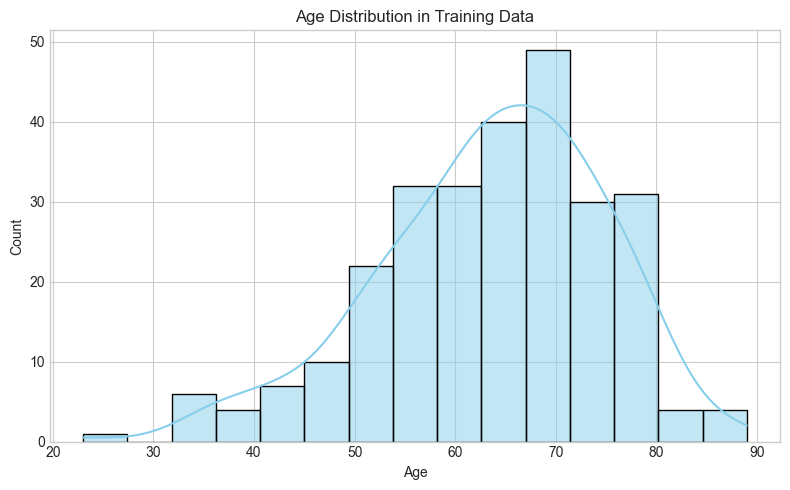

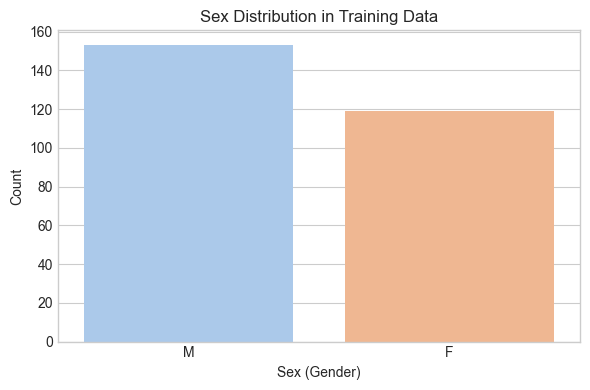

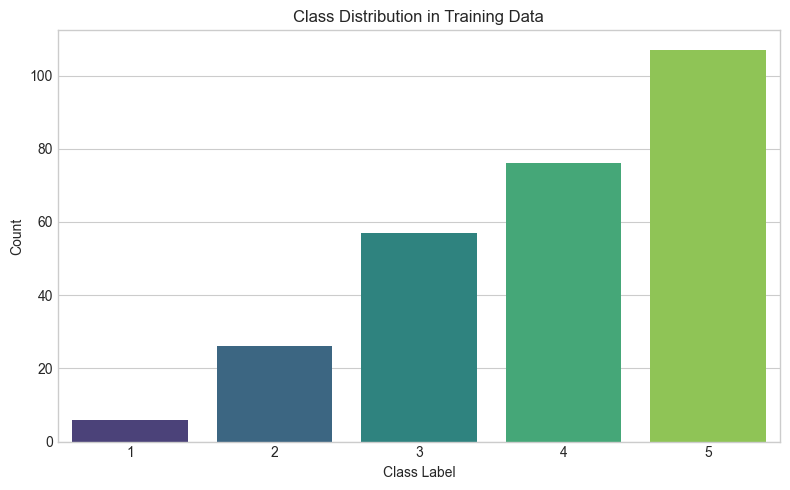

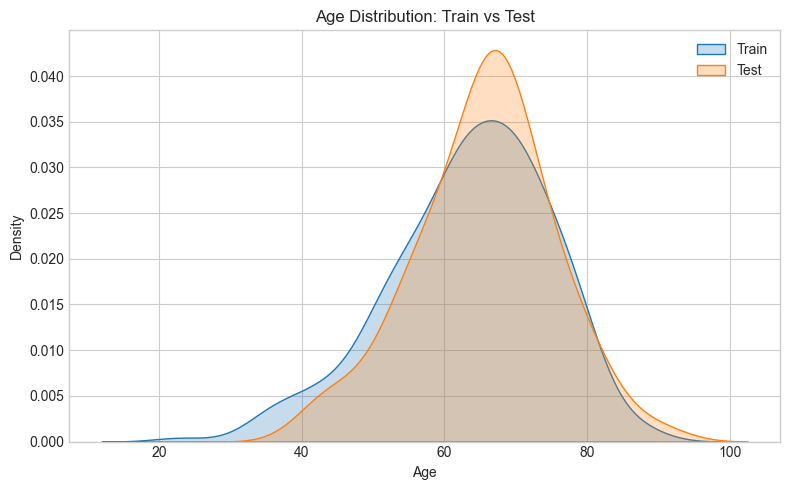

In [25]:
# =========================================================
# Cell 3: Data Summary and Distribution Plots
# =========================================================
print("TRAIN DATA SUMMARY")
display(train_df.describe(include="all"))

print("\nTEST DATA SUMMARY")
display(test_df.describe(include="all"))

# --- Age Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(train_df['Age'], bins=15, kde=True, color='skyblue')
plt.title("Age Distribution in Training Data")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Sex Distribution ---
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=train_df, palette='pastel')
plt.title("Sex Distribution in Training Data")
plt.xlabel("Sex (Gender)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Class Distribution ---
plt.figure(figsize=(8,5))
sns.countplot(x='Class', data=train_df, palette='viridis')
plt.title("Class Distribution in Training Data")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Age Comparison: Train vs Test ---
plt.figure(figsize=(8,5))
sns.kdeplot(train_df['Age'], label='Train', fill=True)
sns.kdeplot(test_df['Age'], label='Test', fill=True)
plt.title("Age Distribution: Train vs Test")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()



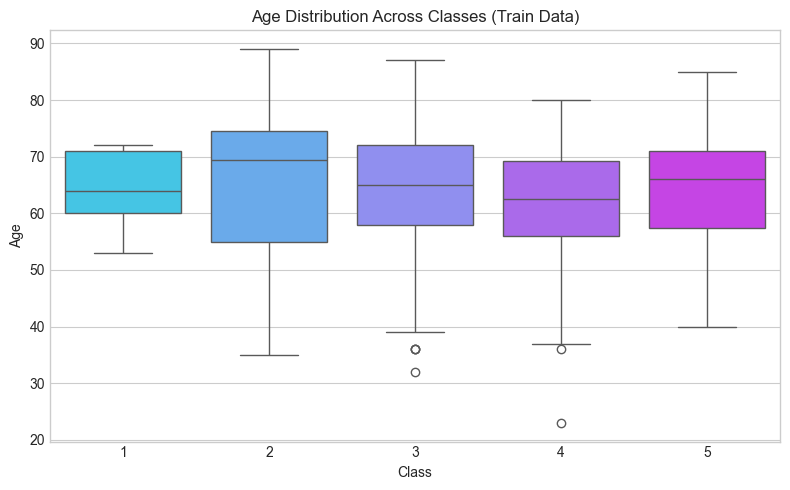

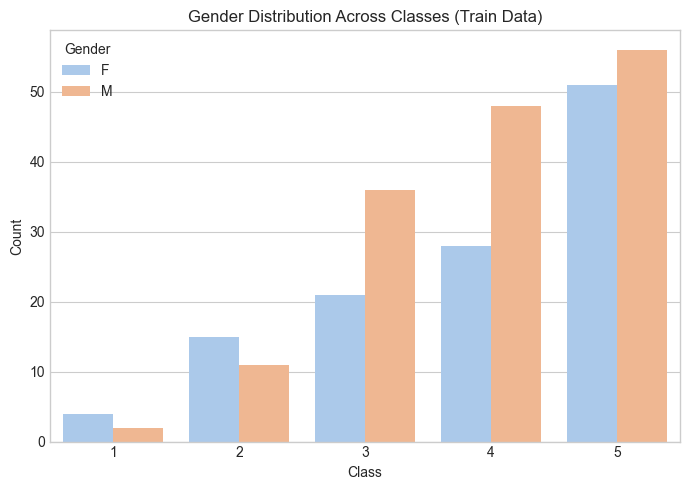

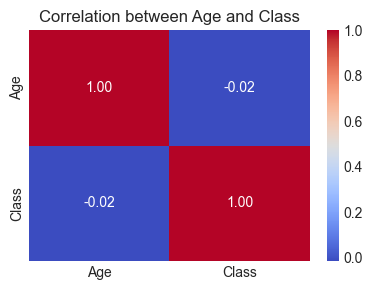

 Average Age in Training Set: 63.51
 Male Count: 153
 Female Count: 119
 Correlation (Age vs Class): -0.02


In [26]:
# Cell 4: Correlation & Relationship Analysis

# ------------------------------
# 1 Age vs Class Relationship
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Age', data=train_df, palette='cool')
plt.title("Age Distribution Across Classes (Train Data)")
plt.xlabel("Class")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# ------------------------------
# 2 Gender vs Class Relationship
plt.figure(figsize=(7,5))
sns.countplot(x='Class', hue='Sex', data=train_df, palette='pastel')
plt.title("Gender Distribution Across Classes (Train Data)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# ------------------------------
# 3 Correlation Heatmap
corr = train_df[['Age', 'Class']].corr(numeric_only=True)
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Age and Class")
plt.tight_layout()
plt.show()

# ------------------------------
# 4 Summary Statements
avg_age = train_df['Age'].mean()
male_count = (train_df['Sex'] == 'M').sum()
female_count = (train_df['Sex'] == 'F').sum()

print(f" Average Age in Training Set: {avg_age:.2f}")
print(f" Male Count: {male_count}")
print(f" Female Count: {female_count}")
print(f" Correlation (Age vs Class): {corr.loc['Age', 'Class']:.2f}")


In [27]:
# Cell 5: Save Plots to PDF
from matplotlib.backends.backend_pdf import PdfPages

pdf_filename = os.path.join(plots_dir, "EDA_Plots_Report.pdf")

with PdfPages(pdf_filename) as pdf:

    # 1 Age Distribution
    plt.figure(figsize=(8,5))
    sns.histplot(train_df['Age'], bins=15, kde=True, color='skyblue')
    plt.title("Age Distribution in Training Data")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 2 Sex Distribution
    plt.figure(figsize=(6,4))
    sns.countplot(x='Sex', data=train_df, palette='pastel')
    plt.title("Sex Distribution in Training Data")
    plt.xlabel("Sex (Gender)")
    plt.ylabel("Count")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 3 Class Distribution
    plt.figure(figsize=(8,5))
    sns.countplot(x='Class', data=train_df, palette='viridis')
    plt.title("Class Distribution in Training Data")
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 4 Age Distribution: Train vs Test
    plt.figure(figsize=(8,5))
    sns.kdeplot(train_df['Age'], label='Train', fill=True)
    sns.kdeplot(test_df['Age'], label='Test', fill=True)
    plt.title("Age Distribution: Train vs Test")
    plt.xlabel("Age")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 5 Age vs Class Boxplot
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Class', y='Age', data=train_df, palette='cool')
    plt.title("Age Distribution Across Classes (Train Data)")
    plt.xlabel("Class")
    plt.ylabel("Age")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6 Gender vs Class Countplot
    plt.figure(figsize=(7,5))
    sns.countplot(x='Class', hue='Sex', data=train_df, palette='pastel')
    plt.title("Gender Distribution Across Classes (Train Data)")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.legend(title='Gender')
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 7 Correlation Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation between Age and Class")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

print(f"All plots saved successfully in {pdf_filename}")


All plots saved successfully in d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\EDA_Plots_Report.pdf


In [28]:
# Cell 6: Summary Table in PDF
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.table as tbl

pdf_filename = os.path.join(plots_dir, "EDA_Plots_Report_with_Summary.pdf")

with PdfPages(pdf_filename) as pdf:

    # ------------------------------
    # 1 Reuse previous plots
    # (Age Distribution)
    plt.figure(figsize=(8,5))
    sns.histplot(train_df['Age'], bins=15, kde=True, color='skyblue')
    plt.title("Age Distribution in Training Data")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # (Sex Distribution)
    plt.figure(figsize=(6,4))
    sns.countplot(x='Sex', data=train_df, palette='pastel')
    plt.title("Sex Distribution in Training Data")
    plt.xlabel("Sex (Gender)")
    plt.ylabel("Count")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # (Class Distribution)
    plt.figure(figsize=(8,5))
    sns.countplot(x='Class', data=train_df, palette='viridis')
    plt.title("Class Distribution in Training Data")
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # (Age Distribution: Train vs Test)
    plt.figure(figsize=(8,5))
    sns.kdeplot(train_df['Age'], label='Train', fill=True)
    sns.kdeplot(test_df['Age'], label='Test', fill=True)
    plt.title("Age Distribution: Train vs Test")
    plt.xlabel("Age")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # (Age vs Class Boxplot)
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Class', y='Age', data=train_df, palette='cool')
    plt.title("Age Distribution Across Classes (Train Data)")
    plt.xlabel("Class")
    plt.ylabel("Age")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # (Gender vs Class Countplot)
    plt.figure(figsize=(7,5))
    sns.countplot(x='Class', hue='Sex', data=train_df, palette='pastel')
    plt.title("Gender Distribution Across Classes (Train Data)")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.legend(title='Gender')
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # (Correlation Heatmap)
    plt.figure(figsize=(4,3))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation between Age and Class")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # ------------------------------
    # 2 Summary Table
    summary_df = train_df.groupby('Class').agg(
        Mean_Age=('Age', 'mean'),
        Male_Count=('Sex', lambda x: (x=='M').sum()),
        Female_Count=('Sex', lambda x: (x=='F').sum()),
        Total_Count=('ID', 'count')
    ).reset_index()

    # Create figure for table
    fig, ax = plt.subplots(figsize=(8,3))
    ax.axis('tight')
    ax.axis('off')
    tbl_table = ax.table(cellText=summary_df.values,
                         colLabels=summary_df.columns,
                         cellLoc='center',
                         loc='center')
    tbl_table.auto_set_font_size(False)
    tbl_table.set_fontsize(10)
    tbl_table.auto_set_column_width([0,1,2,3,4])
    plt.title("Class-wise Summary Table (Age & Gender)", pad=20)
    pdf.savefig()
    plt.close()

print(f"All plots + summary table saved in {pdf_filename}")


All plots + summary table saved in d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\EDA_Plots_Report_with_Summary.pdf
